In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 200


promedio_parcial = np.random.uniform(50, 100, n)
asistencia = np.random.uniform(60, 100, n)
horas_estudio = np.random.uniform(1, 15, n)
accesos_moodle = np.random.randint(5, 60, n)
tareas = np.random.randint(2, 10, n)

calificacion_final = (
    0.35 * promedio_parcial
    + 0.25 * asistencia
    + 1.5 * horas_estudio
    + 0.2 * accesos_moodle
    + 1.2 * tareas
    + np.random.normal(0, 3, n)
)
calificacion_final = np.clip(calificacion_final, 0, 100).round(2)
resultado = np.where(calificacion_final >= 70, "Aprueba", "Reprueba")

df = pd.DataFrame(
    {
        "Promedio_Parcial": promedio_parcial.round(2),
        "Asistencia": asistencia.round(2),
        "Horas_Estudio": horas_estudio.round(2),
        "Accesos_Moodle": accesos_moodle,
        "Tareas": tareas,
        "Calificacion_Final": calificacion_final,
        "Resultado": resultado,
    }
)

df.to_csv("alumnos.csv", index=False)
print("¡Listo! Se creó el archivo alumnos.csv")

¡Listo! Se creó el archivo alumnos.csv


=== MODELO BASE (Árbol de Decisión) ===
Accuracy:  0.8250
Precision: 0.8182
Recall:    0.8571
F1 Score:  0.8372

=== MODELO OPTIMIZADO (Random Forest) ===
Accuracy:  0.9000
Precision: 0.8400
Recall:    1.0000
F1 Score:  0.9130



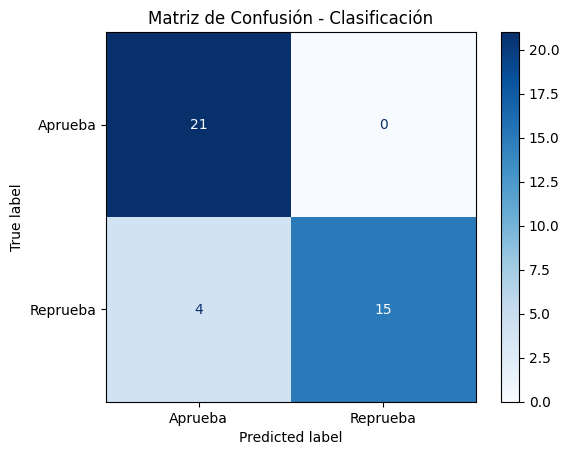

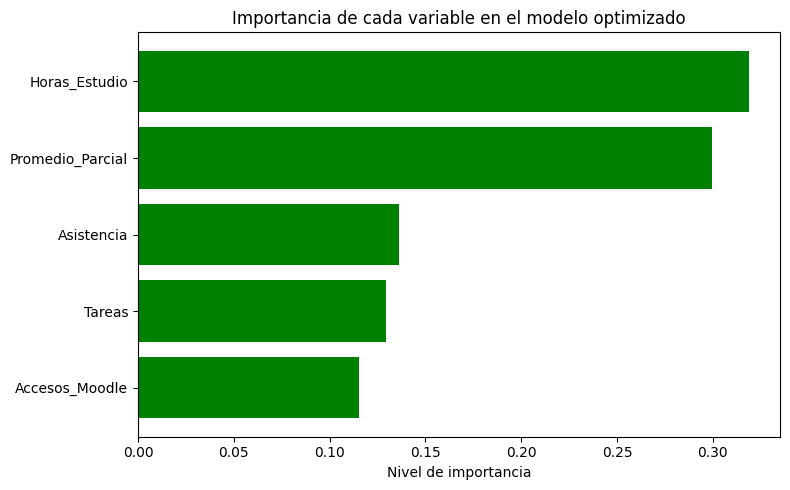

=== PREDICCIONES PARA NUEVOS ALUMNOS ===
Alumno 1: Resultado Predicho -> Aprueba
Alumno 2: Resultado Predicho -> Reprueba


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split


df = pd.read_csv("alumnos.csv")


X = df[
    [
        "Promedio_Parcial",
        "Asistencia",
        "Horas_Estudio",
        "Accesos_Moodle",
        "Tareas",
    ]
]
y = df["Resultado"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.tree import DecisionTreeClassifier

clf_base = DecisionTreeClassifier(random_state=42)
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)

print("=== MODELO BASE (Árbol de Decisión) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(
    f"Precision: {precision_score(y_test, y_pred_base, pos_label='Aprueba'):.4f}"
)
print(
    f"Recall:    {recall_score(y_test, y_pred_base, pos_label='Aprueba'):.4f}"
)
print(
    f"F1 Score:  {f1_score(y_test, y_pred_base, pos_label='Aprueba'):.4f}\n"
)


clf_opt = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
clf_opt.fit(X_train, y_train)
y_pred_opt = clf_opt.predict(X_test)

print("=== MODELO OPTIMIZADO (Random Forest) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
print(
    f"Precision: {precision_score(y_test, y_pred_opt, pos_label='Aprueba'):.4f}"
)
print(
    f"Recall:    {recall_score(y_test, y_pred_opt, pos_label='Aprueba'):.4f}"
)
print(
    f"F1 Score:  {f1_score(y_test, y_pred_opt, pos_label='Aprueba'):.4f}\n"
)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_opt, labels=clf_opt.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=clf_opt.classes_
)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Clasificación")
plt.savefig("graficas.png")
plt.show()


importancias = clf_opt.feature_importances_
variables = X.columns

df_imp = pd.DataFrame(
    {"Variable": variables, "Importancia": importancias}
).sort_values("Importancia", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_imp["Variable"], df_imp["Importancia"], color="green")
plt.xlabel("Nivel de importancia")
plt.title("Importancia de cada variable en el modelo optimizado")
plt.tight_layout()
plt.savefig("importancia_clasificacion.png")
plt.show()

nuevos_alumnos = pd.DataFrame(
    [
        [85, 90, 8, 35, 8],  # Alumno 1 (Buen rendimiento)
        [50, 65, 2, 10, 3],  # Alumno 2 (Bajo rendimiento)
    ],
    columns=X.columns,
)

predicciones = clf_opt.predict(nuevos_alumnos)

print("=== PREDICCIONES PARA NUEVOS ALUMNOS ===")
for i, pred in enumerate(predicciones):
  print(f"Alumno {i+1}: Resultado Predicho -> {pred}")